In [14]:
from lemons import *
# for documentation, open lemons/docs/build/html/index.html

In [21]:
#pick your favorite star.
star_id = 'GAIA DR3 4690516677131714432' 

star_info = get_star_info(star_id) #searching some info in online catalogues. Results are stored, so it will run quicker the second time.
print(star_info.keys())

dict_keys(['star_id', 'GAIA_id', 'Tmag', 'observed_sectors', 'ra', 'dec'])


In [22]:
#Check in which TESS sectors, this star has been observed
print(star_info['observed_sectors'])

[1, 27, 28, 67, 68, 94, 95]


In [30]:
# choose a sector
sector=67

#download the TargetPixelFile
coordinates = str(star_info['ra'])+' '+str(star_info['dec'])
tpf = read_tpf(star_id,sector,coord=coordinates) #will be downloaded when ran for the first time.

if not tpf_roughqualitycheck_succesful(tpf): #mainly checks if target is not off or close to the CCD edge
    print('TPF quality check failed')
else:
    print('TPF quality check successful')


Searching TPF of GAIA DR3 4685945010910000640
Download finished.
TPF quality check successful


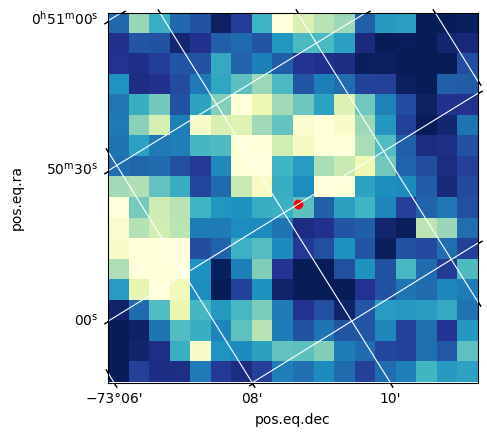

In [31]:
#fancy_tpf_plot(tpf,star_id,save_fig=False)
quick_tpf_plot(tpf)
#see quickt_tpf_plot() for a simpler and quicker version

314


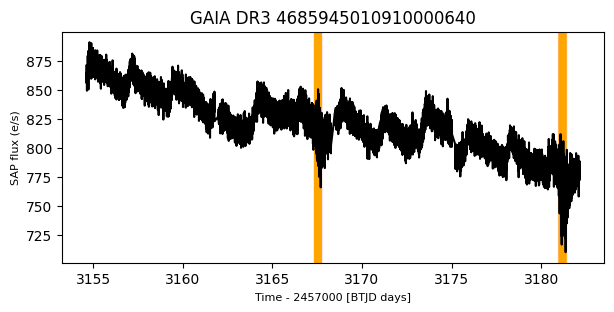

In [39]:
#Let's start with a Simple Aperature Photometry light curve
time,flux_sap = get_raw_sap_lc(star_id, sector, mask_type='3x3',save_lc=True)


fig = plt.figure(figsize=(7,3))
plt.title(star_id)
plt.plot(time,flux_sap,c='black')

flags =  np.load(f'data/{star_id}/sector_{sector}/flags.npy')
tessflag_times = []
for j in range(len(flags)):
    if flags[j]!=0:
        tessflag_times.append(time[j])
print(len(tessflag_times))
for t in tessflag_times:
    plt.axvline(t,alpha=0.1,c='orange',zorder=-1)
    
plt.xlabel('Time - 2457000 [BTJD days]',fontsize=8)
plt.ylabel('SAP flux (e/s)',fontsize=8)
plt.show()

see photutils.psf documentation for more explanation.
    flux_init           flux_fit           flux_err     
------------------ ------------------ ------------------
 4824.043985726889 1690.4184545019834 241.42766796948902
10434.010250809331  4266.168471275123 240.81837047284742
      x_init            x_fit              x_err       
----------------- ----------------- -------------------
9.160460960590516 9.064458598348418 0.10097857473492727
6.722417501265204 6.876242626829499 0.04342064502206916
      y_init            y_fit              y_err       
----------------- ----------------- -------------------
9.670498278602071 9.592404049407946 0.09868885201880044
 8.25410923698059 8.012070683493098 0.04216974795007646
fwhm_init      fwhm_fit            fwhm_err     
--------- ------------------ -------------------
      1.0 1.6998319615213882 0.20234012089322534
      1.0 1.7462534406503476 0.07669732054807779
distances from gaia position: [0.12375444 0.2867836 ]
 id group_id        

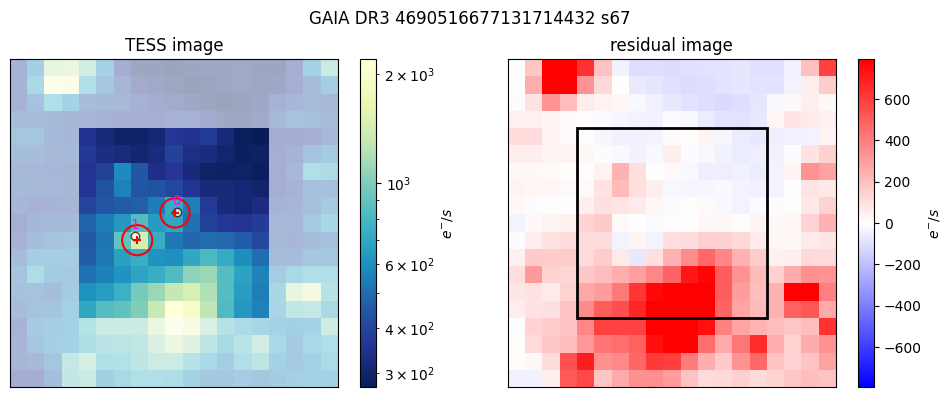

In [7]:
#let's choose which stars to include.
#fit_input is just a collection of information, easy to pass along other methods.
fit_input = create_fit_input(star_id, 
            sector=sector, 
            max_Tmag=12, #all stars below x Tmag are ignored
            radius_inculded=3, #all stars further than x pixellengths are ignored 
            cutoutsize=11, #decide on a smaller subimage, to speed things up a bit, pixels outside the cutout are ignored for PSF fit, but included in the background estimation
            )

check_fit_input_plot(fit_input) #visual check, see documentation for more parameter options
#red circles are FWHM

In [ ]:
#once you are happy with how it looks, you can perform the fit for all cadances
fit_results = get_psf_fit_results(fit_input,overwrite=False)
 
plot_psf_fitted_fluxes(fit_results) #This lightcurve shows the targets PSF flux, i.e. the "volume" under the fitted gaussian.

this might take a couple minutes... Feel free to grab a coffee.
The counter below displays every 5% step reached.
5 10 15 20 25 

In [ ]:
#The blue lightcurve above shows the targets and neigbour PSF flux, i.e. the "volume" under their fitted gaussians.
#This information can also be accessed as follows:
    
n_cad = len(fit_results['fit_results'])
k = 0 # 0 is the target, higher integers for the included neigbours, these indices correspond with what is plotted in the check_fit_input_plot, increasing with apparent distance.
flux_psf = [fit_results['fit_results'][i]['flux_fit'][k] for i in range(n_cad)]

fig = plt.figure(figsize=(7,3))
plt.title(star_id)
plt.plot(time,flux_sap/np.median(flux_sap),c='black',label='SAP flux')
plt.plot(time,flux_psf/np.median(flux_psf),c='C0',label='PSF flux')

plt.xlabel('Time - 2457000 [BTJD days]',fontsize=8)
plt.ylabel('Normalised flux',fontsize=8)
plt.legend()
plt.show()

In [ ]:
#Check out documentation for many more methods, plots and options.
# see lemons/docs/build/html/index.html